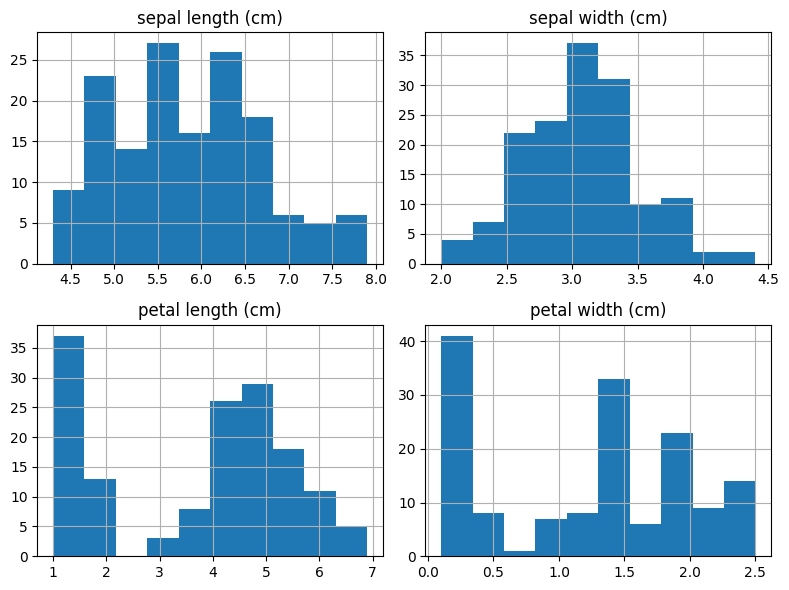

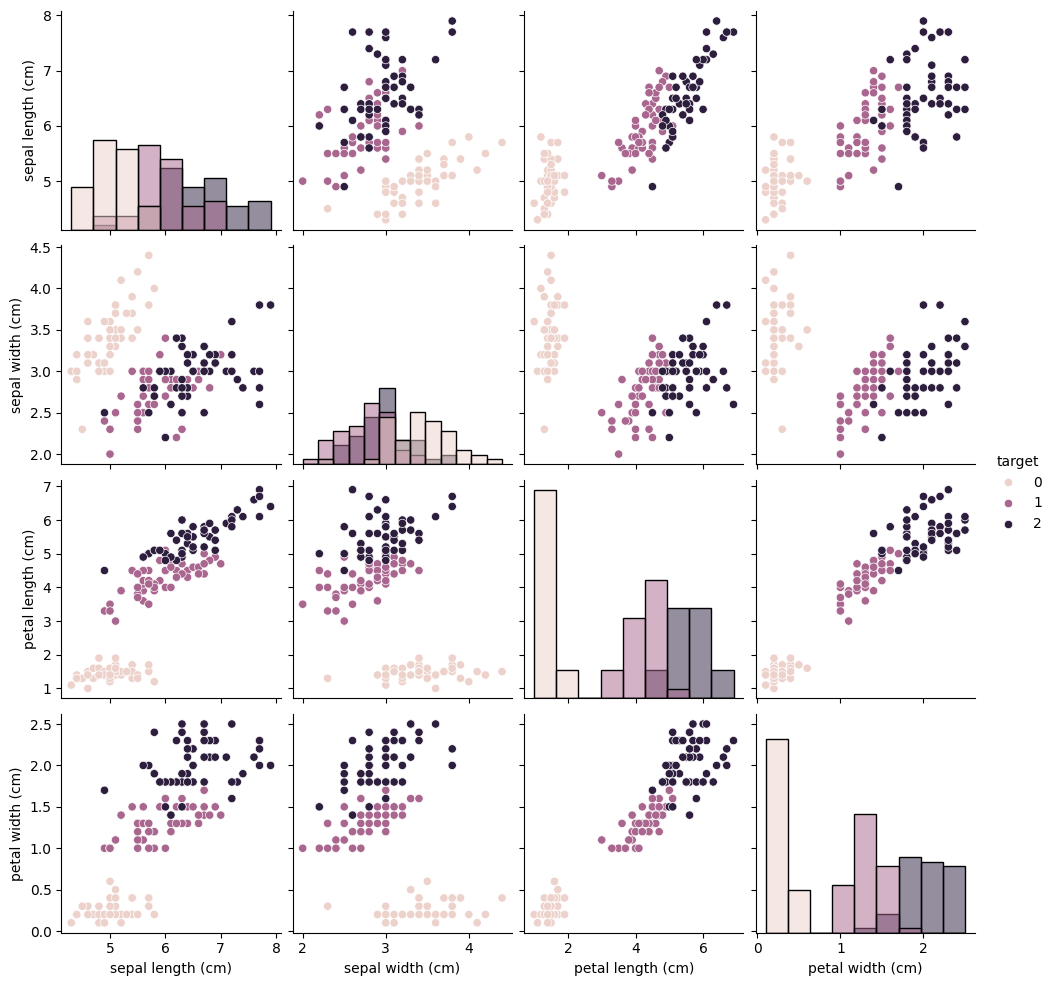

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import confusion_matrix, adjusted_rand_score

# Load dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="target")

# First few rows
X.head()

# Summary statistics
X.describe()

# Histograms
X.hist(figsize=(8, 6))
plt.tight_layout()
plt.show()

# Pair plot colored by true labels
df = X.copy()
df["target"] = y
sns.pairplot(df, hue="target", diag_kind="hist")
plt.show()



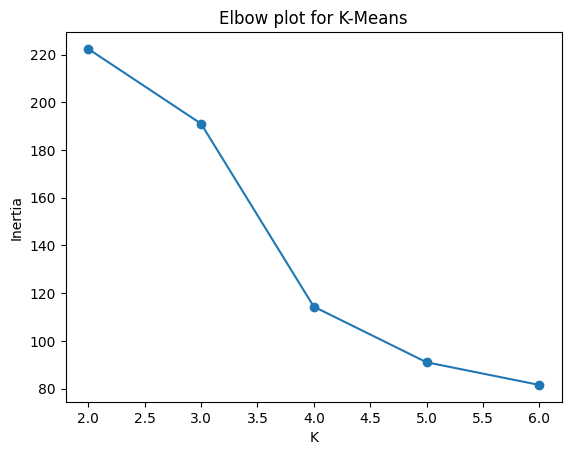

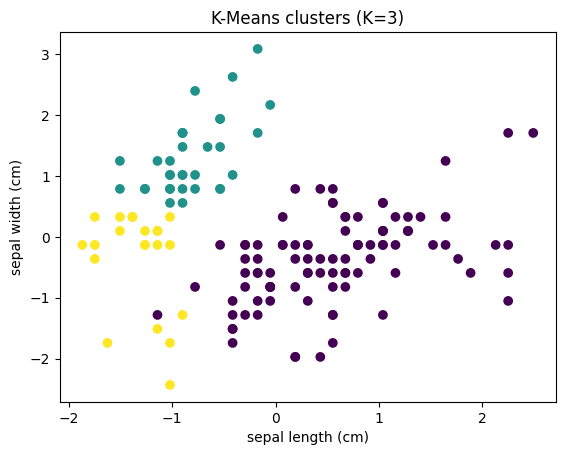

Confusion matrix:
 [[ 0 33 17]
 [46  0  4]
 [50  0  0]]
Adjusted Rand Index: 0.432804702527474


In [ ]:
# Optional: scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Try different K values
inertias = []
Ks = range(2, 7)
for k in Ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(Ks, inertias, marker="o")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow plot for K-Means")
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42)
labels_km = kmeans.fit_predict(X_scaled)

# 2D scatter using first two features
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_km, cmap="viridis")
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title("K-Means clusters (K=3)")
plt.show()

cm = confusion_matrix(y, labels_km)
ari = adjusted_rand_score(y, labels_km)
print("Confusion matrix:\n", cm)
print("Adjusted Rand Index:", ari)


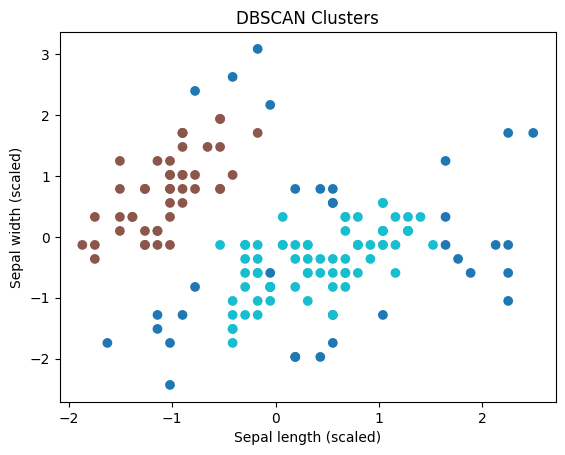

0.4420986685885924

In [ ]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=5)
labels_db = db.fit_predict(X_scaled)

unique_labels = set(labels_db)
unique_labels

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_db, cmap="tab10")
plt.xlabel("Sepal length (scaled)")
plt.ylabel("Sepal width (scaled)")
plt.title("DBSCAN Clusters")
plt.show()

ari_db = adjusted_rand_score(y, labels_db)
ari_db
